In [7]:
import joblib
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score , classification_report
data = pd.read_csv("../data/output.csv")


X = data.drop("Churn_Yes", axis=1)
y = data["Churn_Yes"]

X_train,X_test,y_train,y_test = train_test_split(X , y , test_size = 0.2 , random_state = 1 , stratify=y)


lr_model = joblib.load("../models/logistic_regression.pkl")
best_d_model = joblib.load("../models/Dicision_tree.pkl")
best_model = joblib.load("../models/random_forest.pkl")
xgb_model  = joblib.load("../models/xgboost.pkl")

print("run successfully")

run successfully


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


y_pred_lr = lr_model.predict(X_test_scaled)
y_pred = best_d_model.predict(X_test)
y_pred_grid = best_model.predict(X_test)
y_pred_xgb = xgb_model.predict(X_test)


comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_grid),
        accuracy_score(y_test, y_pred_xgb)
    ],

    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_grid),
        precision_score(y_test, y_pred_xgb)
    ],

    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_grid),
        recall_score(y_test, y_pred_xgb)
    ],

    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_grid),
        f1_score(y_test, y_pred_xgb)
    ]

})

print(comparison)

print()
print("Logistic Regression")
print(classification_report(y_test, y_pred_lr))

print("Decision Tree")
print(classification_report(y_test, y_pred))

print("Random Forest")
print(classification_report(y_test, y_pred_grid))

print("XGBoost")
print(classification_report(y_test, y_pred_xgb))

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.781405   0.601227  0.524064  0.560000
1        Decision Tree  0.786373   0.681592  0.366310  0.476522
2        Random Forest  0.687012   0.450075  0.807487  0.577990
3              XGBoost  0.799858   0.661972  0.502674  0.571429

Logistic Regression
              precision    recall  f1-score   support

       False       0.84      0.87      0.85      1035
        True       0.60      0.52      0.56       374

    accuracy                           0.78      1409
   macro avg       0.72      0.70      0.71      1409
weighted avg       0.77      0.78      0.78      1409

Decision Tree
              precision    recall  f1-score   support

       False       0.80      0.94      0.87      1035
        True       0.68      0.37      0.48       374

    accuracy                           0.79      1409
   macro avg       0.74      0.65      0.67      1409
weighted avg       0.77      0.79      0.76   

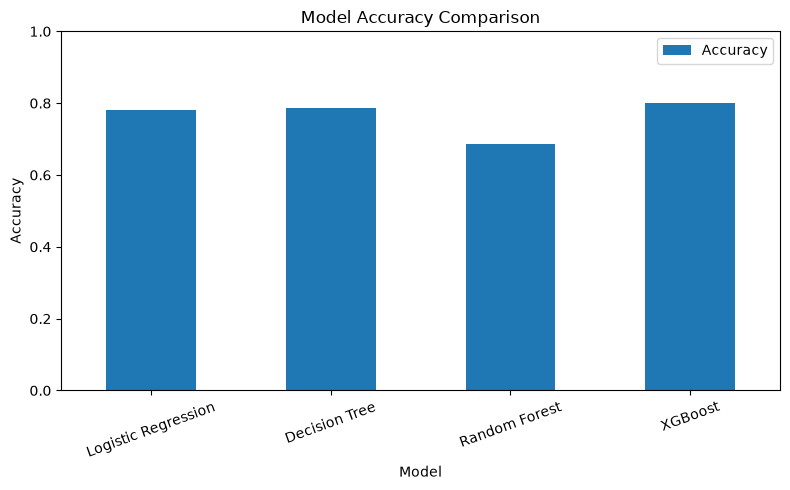

In [9]:
comparison.plot(
    x="Model",
    y="Accuracy",
    kind="bar",
    figsize=(8, 5)
)

plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()